# DataVine Analytics: Machine Learning Applications

## Project Overview

DataVine Analytics is a consulting group that develops machine learning solutions for organizations across different industries. This project applies a complete machine learning workflow to three different business problems involving classification, recommendation, and clustering.

The first project focuses on a **Wine Classification System**, where a premium wine distributor needs to automatically classify wine varieties based on their chemical properties. A k-Nearest Neighbors (k-NN) classification model will be developed and optimized using Principal Component Analysis (PCA) and hyperparameter tuning.

The second project develops an **Agricultural Feed Recommendation Engine** using the `Chickwts` dataset as a proxy for feed performance. PCA and cosine similarity will be used to identify feed types with similar performance characteristics and generate recommendations.

The third project addresses **Regional Crime Pattern Analysis** using the `USArrests` dataset. K-Means and Gaussian Mixture Model (GMM) clustering will be used to identify natural groupings among regions based on crime statistics. PCA will also be used to reduce the dimensionality of the selected features and visualize the resulting clusters.

Across all three projects, the analysis follows a structured machine learning workflow: data preparation, exploratory analysis, feature scaling, dimensionality reduction, model development, hyperparameter optimization where appropriate, evaluation, visualization, and interpretation.

The goal is not only to build technically appropriate machine learning models, but also to translate their results into meaningful insights that could support business and organizational decision-making.

## Project Roadmap

This notebook is organized into three independent machine learning applications, each addressing a different type of analytical problem.

| Project | Business Problem | Machine Learning Approach | Main Output |
|---|---|---|---|
| Wine Classification | Automatically identify wine varieties | PCA + k-NN + GridSearchCV | Predicted wine class |
| Feed Recommendation | Identify similar-performing feed types | PCA + Cosine Similarity | Similar feed recommendations |
| Crime Pattern Analysis | Identify regions with similar crime patterns | PCA + K-Means + GMM | Regional clusters |

Although the three projects use different machine learning techniques, they follow the same underlying workflow:

**Understand the data → Prepare the data → Transform the features → Apply the appropriate technique → Evaluate the results → Interpret the findings**

In [4]:
#import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.pipeline import Pipeline

# 1. Dataset Preparation

Before applying any machine learning technique, the datasets must be inspected and prepared to ensure that the models receive reliable and appropriately formatted inputs.

The three datasets represent different analytical problems and therefore have different structures. The Wine dataset contains chemical measurements and a categorical wine class, the Chickwts dataset contains feed types and chicken weight measurements, and the USArrests dataset contains regional crime statistics.

The preparation stage will focus on:

- Loading each dataset correctly
- Inspecting the number of observations and variables
- Identifying numerical and categorical variables
- Checking for missing values
- Checking for duplicate or inconsistent records
- Reviewing descriptive statistics
- Identifying potential data quality issues
- Standardizing numerical features where required

The objective is to understand the characteristics of each dataset before selecting and applying the appropriate machine learning technique.

In [5]:
# Load each CSV dataset into a separate DataFrame.

wine = pd.read_csv("wine.csv")
chickwts = pd.read_csv("chickwts.csv")
us_arrests = pd.read_csv("USArrests.csv")

In [6]:
# Display the first five rows of each dataset
# to understand the variables and the way the data is structured.

print("WINE DATASET")
display(wine.head())

print("\nCHICKWTS DATASET")
display(chickwts.head())

print("\nUSARRESTS DATASET")
display(us_arrests.head())

WINE DATASET


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0



CHICKWTS DATASET


,weight,feed
0,179,horsebean
1,160,horsebean
2,136,horsebean
3,227,horsebean
4,217,horsebean



USARRESTS DATASET


,rownames,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6


In [7]:
# Check the number of rows and columns in each dataset.

print("Wine shape:", wine.shape)
print("Chickwts shape:", chickwts.shape)
print("USArrests shape:", us_arrests.shape)

Wine shape: (178, 14)
Chickwts shape: (71, 2)
USArrests shape: (50, 5)


In [8]:
# Inspect data types and identify potential formatting issues.

print("WINE DATASET")
wine.info()

print("\nCHICKWTS DATASET")
chickwts.info()

print("\nUSARRESTS DATASET")
us_arrests.info()

WINE DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float

In [9]:
# Check for missing values and duplicate rows in each dataset.

datasets = {
    "Wine": wine,
    "Chickwts": chickwts,
    "USArrests": us_arrests
}

for name, data in datasets.items():
    print(f"\n{name} Dataset")
    print("-" * 30)
    print("Missing values:")
    print(data.isnull().sum())
    print("Duplicate rows:", data.duplicated().sum())


Wine Dataset
------------------------------
Missing values:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64
Duplicate rows: 0

Chickwts Dataset
------------------------------
Missing values:
weight    0
feed      0
dtype: int64
Duplicate rows: 1

USArrests Dataset
------------------------------
Missing values:
rownames    0
Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64
Duplicate rows: 0


In [10]:
# Generate descriptive statistics for the numerical variables
# in each dataset.

print("WINE DATASET")
display(wine.describe())

print("\nCHICKWTS DATASET")
display(chickwts.describe())

print("\nUSARRESTS DATASET")
display(us_arrests.describe())

WINE DATASET


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000



CHICKWTS DATASET


,weight
count,71.000000
mean,261.309859
std,78.073700
min,108.000000
25%,204.500000
50%,258.000000
75%,323.500000
max,423.000000



USARRESTS DATASET


,Murder,Assault,UrbanPop,Rape
count,50.00000,50.000000,50.000000,50.000000
mean,7.78800,170.760000,65.540000,21.232000
std,4.35551,83.337661,14.474763,9.366385
min,0.80000,45.000000,32.000000,7.300000
25%,4.07500,109.000000,54.500000,15.075000
50%,7.25000,159.000000,66.000000,20.100000
75%,11.25000,249.000000,77.750000,26.175000
max,17.40000,337.000000,91.000000,46.000000


In [11]:
# Check the number of observations in each wine class.
# This helps us understand whether the classification target is balanced.

print("Wine target distribution:")
print(wine["target"].value_counts().sort_index())


# Check how many observations belong to each feed type.
# This helps us understand the representation of each feed
# before calculating similarities.

print("\nChickwts feed distribution:")
print(chickwts["feed"].value_counts())


# Inspect the region names stored in the identifier column.

print("\nUSArrests regions:")
print(us_arrests["rownames"].tolist())

Wine target distribution:
target
0    59
1    71
2    48
Name: count, dtype: int64

Chickwts feed distribution:
feed
soybean      14
linseed      12
sunflower    12
casein       12
meatmeal     11
horsebean    10
Name: count, dtype: int64

USArrests regions:
['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']


In [12]:
# Display the duplicate row(s) in the Chickwts dataset.
# This allows us to determine whether the duplicate represents
# a genuine repeated observation or a possible data-entry issue.

chickwts[chickwts.duplicated(keep=False)]

,weight,feed
24,248,soybean
35,248,soybean


In [13]:
# Remove duplicate rows from the Chickwts dataset.
# keep="first" keeps the first occurrence and removes subsequent duplicates.

chickwts = chickwts.drop_duplicates()

In [14]:
print("Chickwts shape after removing duplicates:", chickwts.shape)
print("Duplicate rows:", chickwts.duplicated().sum())

Chickwts shape after removing duplicates: (70, 2)
Duplicate rows: 0


## 1.3 Data Quality Findings

The initial data-quality assessment shows that the three datasets are generally complete and suitable for further analysis.

- The **Wine dataset** contains no missing values and no duplicate records.
- The **Chickwts dataset** contains no missing values but initially contained one duplicate record. The duplicate consisted of two identical observations with a weight of 248 and a feed type of soybean. One duplicate record was removed to prevent the same observation from being counted twice.
- The **USArrests dataset** contains no missing values or duplicate records.

The datasets therefore require minimal cleaning. The main preparation steps will focus on appropriate feature selection and standardization before applying PCA, classification, recommendation, and clustering techniques.

Importantly, standardization will be performed within each project rather than modifying the original datasets during the general data-preparation stage.

# 2. Wine Classification System

## 2.1 Business Problem

DataVine Analytics has been asked to develop an automated wine classification system for a premium wine distributor. The objective is to classify wine varieties based on their chemical properties.

Accurate classification can support inventory management and quality control by providing a data-driven method for identifying wine varieties from their chemical measurements.

A **k-Nearest Neighbors (k-NN)** classification model will be developed, with **Principal Component Analysis (PCA)** used to reduce dimensionality while retaining 95% of the information in the original features. GridSearchCV will then be used to identify suitable k-NN hyperparameters.

In [15]:
# Separate the chemical features from the target variable.

X = wine.drop(columns="target")
y = wine["target"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("Target classes:", sorted(y.unique()))

Feature shape: (178, 13)
Target shape: (178,)
Target classes: [0, 1, 2]


In [16]:
# Split the data into training and testing sets.
# stratify=y maintains the proportion of wine classes in both sets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (142, 13)
Testing set: (36, 13)


In [17]:
# Create a pipeline that standardizes the features and then applies PCA.
# PCA will retain enough components to explain 95% of the variance.

wine_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("knn", KNeighborsClassifier())
])

# Fit the preprocessing and model on the training data only.
wine_pipeline.fit(X_train, y_train)

# Check how many principal components were required.
n_components = wine_pipeline.named_steps["pca"].n_components_

print("Original number of features:", X_train.shape[1])
print("Number of PCA components:", n_components)

Original number of features: 13
Number of PCA components: 10


## 2.2 Building and Optimizing the k-NN Model

After standardizing the Wine dataset and reducing its dimensionality using PCA, the next step is to build the classification model.

We will use **k-Nearest Neighbors (k-NN)** because the algorithm classifies an observation based on the classes of nearby observations. Since wine samples with similar chemical properties may belong to the same wine variety, distance-based classification is appropriate for this problem.

The performance of k-NN depends on hyperparameters such as:

- **n_neighbors (`k`)**: determines how many nearby observations are considered when making a prediction.
- **metric**: determines how the distance between observations is calculated.

Rather than selecting these values manually, **GridSearchCV** will systematically test different combinations of hyperparameters using cross-validation.

Cross-validation allows the training data to be divided into multiple folds. The model is trained and validated across different combinations of these folds, producing a more reliable estimate of how each parameter combination performs.

The model with the best cross-validation performance will then be selected and evaluated on the separate test set, which has not been used during model selection.

In [18]:
# Define the hyperparameters we want GridSearchCV to test.
# n_neighbors controls how many nearby observations are used for classification.
# metric controls how distance between observations is calculated.

param_grid = {
    "knn__n_neighbors": range(1, 21),
    "knn__metric": ["euclidean", "manhattan"]
}

# Create GridSearchCV using our existing pipeline.
# The pipeline ensures that scaling and PCA are performed correctly
# within each cross-validation fold.

grid_search = GridSearchCV(
    estimator=wine_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Fit GridSearchCV using only the training data.
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

Best parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 18}
Best cross-validation accuracy: 0.9790640394088669


## 2.3 Final Model Evaluation

GridSearchCV identified **18 neighbors** and the **Euclidean distance metric** as the best-performing combination based on 5-fold cross-validation.

The selected model will now be evaluated on the test dataset. The test data was kept separate during model training and hyperparameter tuning, allowing us to assess how well the optimized model generalizes to previously unseen wine samples.

We will use accuracy and a classification report to evaluate the model's performance across the three wine classes.

In [19]:
# Get the best-performing model identified by GridSearchCV.
best_wine_model = grid_search.best_estimator_

# Use the optimized model to predict the wine classes
# in the unseen test dataset.
y_pred = best_wine_model.predict(X_test)

# Calculate the overall test accuracy.
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 1.0000


In [20]:
# Generate a detailed classification report showing
# precision, recall, and F1-score for each wine class.

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



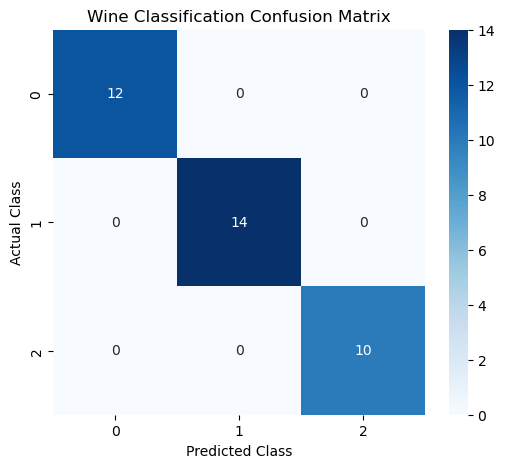

In [21]:
# Create a confusion matrix to compare the actual
# wine classes with the model's predicted classes.

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Wine Classification Confusion Matrix")
plt.show()

## 2.4 Model Performance and Interpretation

The optimized k-NN model achieved a **test accuracy of 100%** on the 36 unseen wine observations.

The classification report shows that all three wine classes achieved:

- **Precision = 1.00**
- **Recall = 1.00**
- **F1-score = 1.00**

The confusion matrix confirms that there were **no misclassified observations**. All 12 Class 0 wines, 14 Class 1 wines, and 10 Class 2 wines were correctly identified.

This indicates that the chemical characteristics in the dataset provide strong information for distinguishing between the three wine classes. The combination of feature standardization, PCA, and optimized k-NN produced highly accurate classifications on this particular test split.

The model's **97.91% cross-validation accuracy** was slightly lower than its 100% test accuracy. This difference is expected because cross-validation evaluates the model across multiple validation folds, while the test accuracy is based on one held-out test set.

The 100% test accuracy should therefore be interpreted as performance on this specific test sample rather than evidence that the model will achieve perfect accuracy on all future wine samples.

# 3. Agricultural Feed Recommendation Engine

## 3.1 Business Problem

DataVine Analytics has been asked to develop a prototype recommendation system for an agricultural supply company. The company wants to identify feed types that produce similar chicken growth outcomes, which can help support product comparison and feed recommendations.

The `Chickwts` dataset contains chicken weight measurements associated with different feed types. In this analysis, chicken weight is used as a proxy for feed performance.

Unlike the Wine project, this is not a classification problem. Instead, we want to measure the similarity between feed types based on their observed performance.

The analysis will:

1. Standardize chicken weight to ensure consistent scaling.
2. Apply Principal Component Analysis (PCA) to reduce the standardized data to one principal component.
3. Calculate cosine similarity between observations.
4. Aggregate the similarity information by feed type to identify comparable feed products.
5. Use the similarity scores to generate feed recommendations.

The resulting recommendations should be interpreted as **similarity-based suggestions**, rather than evidence that one feed causes better chicken growth than another.

## 3.2 Understanding Feed Performance

Before calculating similarity, we examine the chicken weight associated with each feed type. This allows us to understand how the feed groups differ in their observed performance and provides context for the later similarity analysis.

In [22]:
# Calculate summary statistics for chicken weight by feed type.
# This helps us compare the observed performance of each feed.

feed_summary = (
    chickwts
    .groupby("feed")["weight"]
    .agg(["count", "mean", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)

display(feed_summary)

,count,mean,std,min,max
feed,,,,,
sunflower,12,328.916667,48.836384,226,423
casein,12,323.583333,64.433840,216,404
meatmeal,11,276.909091,64.900623,153,380
soybean,13,246.307692,56.337354,158,329
linseed,12,218.750000,52.235698,141,309
horsebean,10,160.200000,38.625841,108,227


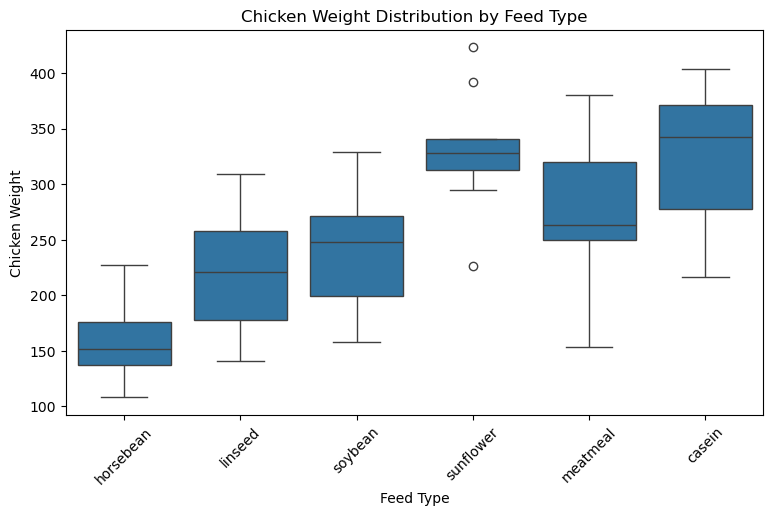

In [23]:
# Visualize the distribution of chicken weights across feed types.

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=chickwts,
    x="feed",
    y="weight"
)

plt.title("Chicken Weight Distribution by Feed Type")
plt.xlabel("Feed Type")
plt.ylabel("Chicken Weight")
plt.xticks(rotation=45)
plt.show()

## 3.3 Standardizing Feed Performance

The feed performance variable, `weight`, is standardized before applying PCA.

Standardization transforms the feature so that it has a mean of approximately 0 and a standard deviation of 1. This places the values on a consistent scale and prepares the data for PCA and similarity calculations.

In [24]:
# Select the numerical feature used to represent feed performance.
X_feed = chickwts[["weight"]]

# Standardize chicken weight.
scaler = StandardScaler()
X_feed_scaled = scaler.fit_transform(X_feed)

print("Original mean:", X_feed["weight"].mean())
print("Standardized mean:", X_feed_scaled.mean())
print("Standardized standard deviation:", X_feed_scaled.std())

Original mean: 261.5
Standardized mean: -1.4274296030894868e-17
Standardized standard deviation: 1.0


## 3.4 Principal Component Analysis

PCA is applied to reduce the standardized feed-performance data to one principal component.

Because the dataset contains only one numerical feature, the single principal component represents the variation in chicken weight. The transformed values provide a standardized numerical representation that can be used for the similarity analysis.

In [25]:
# Reduce the standardized weight data to one principal component.
pca_feed = PCA(n_components=1)

X_feed_pca = pca_feed.fit_transform(X_feed_scaled)

print("PCA shape:", X_feed_pca.shape)
print("Explained variance ratio:", pca_feed.explained_variance_ratio_)

PCA shape: (70, 1)
Explained variance ratio: [1.]


## 3.5 Interpretation of Feed Performance and PCA

The descriptive statistics show noticeable differences in average chicken weight across feed types. Sunflower and casein have the highest average weights, while horsebean has the lowest average weight.

The standardization step was successful, producing a mean close to 0 and a standard deviation of 1.

PCA reduced the standardized weight data to one principal component. The component explains **100% of the variance** because only one numerical feature, chicken weight, is being analyzed. Therefore, no information is lost through this dimensionality-reduction step.

The resulting principal component will now be used to calculate cosine similarity between observations and identify feed types with comparable performance.

## 3.6 Calculating Cosine Similarity

Cosine similarity measures how similar two observations are based on the direction of their feature vectors.

For this analysis, the PCA-transformed weight values are used to calculate similarity between chicken observations. The resulting similarity matrix shows how closely each observation resembles every other observation based on feed performance.

We will then use the feed labels to identify observations belonging to different feed types and generate similarity-based recommendations.

In [26]:
# Calculate cosine similarity between all chicken observations
# using their one-dimensional PCA representation.

similarity_matrix = cosine_similarity(X_feed_pca)

print("Similarity matrix shape:", similarity_matrix.shape)

Similarity matrix shape: (70, 70)


In [27]:
# Create a DataFrame containing each observation's feed type
# and its corresponding PCA representation.

feed_pca = pd.DataFrame({
    "feed": chickwts["feed"].values,
    "pca_component": X_feed_pca.flatten()
})

display(feed_pca.head())

,feed,pca_component
0,horsebean,-1.056916
1,horsebean,-1.300327
2,horsebean,-1.607794
3,horsebean,-0.441983
4,horsebean,-0.570094


In [28]:
# Calculate the average PCA score for each feed type.
# This gives us one representative performance value per feed.

feed_profiles = (
    feed_pca
    .groupby("feed")["pca_component"]
    .mean()
    .to_frame()
)

display(feed_profiles)

,pca_component
feed,
casein,0.795356
horsebean,-1.297765
linseed,-0.547675
meatmeal,0.197408
soybean,-0.194630
sunflower,0.863682


In [29]:
# Calculate cosine similarity between the average PCA profiles
# of the different feed types.

feed_similarity = cosine_similarity(feed_profiles)

feed_similarity_df = pd.DataFrame(
    feed_similarity,
    index=feed_profiles.index,
    columns=feed_profiles.index
)

display(feed_similarity_df.round(3))

feed,casein,horsebean,linseed,meatmeal,soybean,sunflower
feed,,,,,,
casein,1.0,-1.0,-1.0,1.0,-1.0,1.0
horsebean,-1.0,1.0,1.0,-1.0,1.0,-1.0
linseed,-1.0,1.0,1.0,-1.0,1.0,-1.0
meatmeal,1.0,-1.0,-1.0,1.0,-1.0,1.0
soybean,-1.0,1.0,1.0,-1.0,1.0,-1.0
sunflower,1.0,-1.0,-1.0,1.0,-1.0,1.0


## 3.6 Calculating Cosine Similarity

Cosine similarity was calculated using the PCA-transformed feed-performance values to compare the feed types.

The resulting similarity matrix contains values of either **+1.0 or -1.0**. A value of +1.0 indicates that two feed profiles point in the same direction, while -1.0 indicates that they point in opposite directions.

For example, casein, meatmeal, and sunflower have positive similarity with each other, while horsebean, linseed, and soybean have positive similarity with each other. The two groups have negative similarity with each other.

This result is a consequence of reducing the dataset to **one principal component**. Because cosine similarity is being calculated in a one-dimensional space, the measure mainly captures whether feed profiles have the same or opposite direction rather than providing a detailed measure of how close their performance levels are.

Therefore, the similarity results should be interpreted as a **similarity-based grouping of feed types**, rather than evidence that feeds with a similarity of +1.0 have identical performance.


In [30]:
# Create a recommendation table for each feed
recommendations = []

for feed in feed_similarity_df.index:
    # Get similarity scores for the selected feed
    scores = feed_similarity_df.loc[feed].drop(feed)
    
    # Sort from highest similarity to lowest
    similar_feeds = scores.sort_values(ascending=False)
    
    # Select the top 2 similar feeds
    for recommended_feed, score in similar_feeds.head(2).items():
        recommendations.append({
            "Feed": feed,
            "Recommended Feed": recommended_feed,
            "Cosine Similarity": score
        })

recommendation_df = pd.DataFrame(recommendations)

display(recommendation_df)

,Feed,Recommended Feed,Cosine Similarity
0,casein,meatmeal,1.0
1,casein,sunflower,1.0
2,horsebean,linseed,1.0
3,horsebean,soybean,1.0
4,linseed,horsebean,1.0
5,linseed,soybean,1.0
6,meatmeal,casein,1.0
7,meatmeal,sunflower,1.0
8,soybean,horsebean,1.0
9,soybean,linseed,1.0


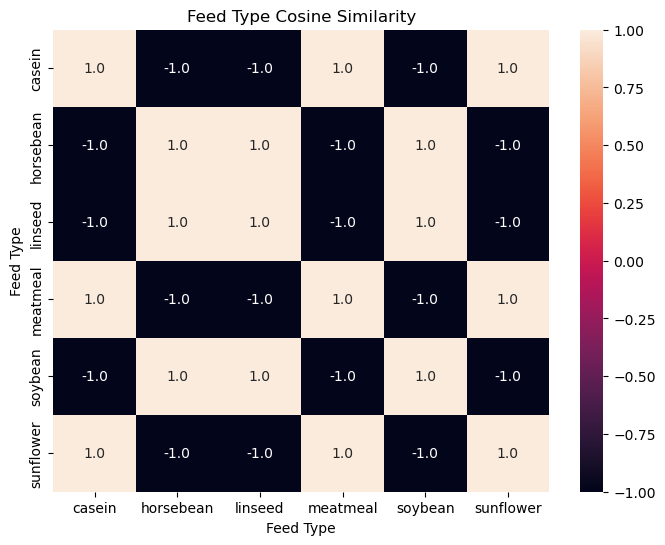

In [31]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    feed_similarity_df,
    annot=True,
    fmt=".1f",
    vmin=-1,
    vmax=1
)

plt.title("Feed Type Cosine Similarity")
plt.xlabel("Feed Type")
plt.ylabel("Feed Type")
plt.show()

## 3.7 Feed Recommendation Results

The cosine similarity analysis identified two main groups of feeds with similar profiles in the one-dimensional PCA space.

The first group consists of **casein, meatmeal, and sunflower**, which have positive cosine similarity with one another. The second group consists of **horsebean, linseed, and soybean**, which also show positive similarity with one another.

Based on the similarity scores, the recommendation system can suggest feeds within the same group. For example, casein can be recommended alongside meatmeal or sunflower, while horsebean can be recommended alongside linseed or soybean.

These recommendations are based on similarity in the transformed performance data and should not be interpreted as evidence that the recommended feeds produce the same or better chicken growth. The one-component PCA representation causes cosine similarity to distinguish mainly between observations on the same or opposite side of the standardized mean.

Overall, the prototype demonstrates how dimensionality reduction and similarity measures can be combined to generate data-driven feed recommendations.


# 4. Regional Crime Pattern Analysis

## 4.1 Business Problem

DataVine Analytics has been asked to analyze regional crime patterns using the `USArrests` dataset. The objective is to identify groups of regions that exhibit similar crime patterns based on reported crime statistics.

Unlike the Wine project, there is no predefined target variable. The goal is therefore not to predict a known outcome, but to discover **natural groupings within the data**.

Two clustering approaches will be compared:

* **K-Means clustering**, which assigns observations to clusters based on their distance from cluster centroids.
* **Gaussian Mixture Model (GMM)**, which models the data as a mixture of probability distributions and assigns observations based on their estimated probability of belonging to each cluster.

The analysis will use the crime-related variables **Murder, Assault, and Rape**. `UrbanPop` will be excluded because it measures population characteristics rather than crime incidence.

The selected variables will be standardized before applying PCA. PCA will then reduce the data to two components, allowing the regional patterns and resulting clusters to be visualized.

The optimal number of clusters will be investigated using:

1. The **K-Means elbow method**, based on within-cluster inertia.
2. **GMM Bayesian Information Criterion (BIC)**, where lower BIC values indicate a better balance between model fit and model complexity.

The final clusters will then be visualized and compared to understand the different regional crime patterns present in the dataset.


In [32]:
# Display the numerical crime variables
crime_features = ["Murder", "Assault", "Rape"]

display(us_arrests[crime_features].head())

,Murder,Assault,Rape
0,13.2,236,21.2
1,10.0,263,44.5
2,8.1,294,31.0
3,8.8,190,19.5
4,9.0,276,40.6


In [33]:
# Examine correlations between the selected crime variables
crime_corr = us_arrests[crime_features].corr()

display(crime_corr.round(2))

,Murder,Assault,Rape
Murder,1.00,0.80,0.56
Assault,0.80,1.00,0.67
Rape,0.56,0.67,1.00


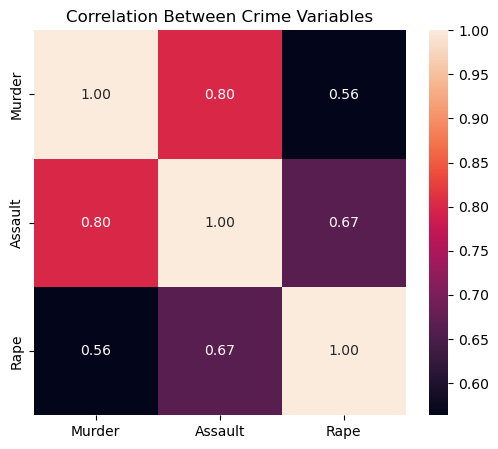

In [34]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    crime_corr,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Between Crime Variables")
plt.show()

In [35]:
# Select the three crime variables
X_crime = us_arrests[crime_features]

# Standardize the features
crime_scaler = StandardScaler()
X_crime_scaled = crime_scaler.fit_transform(X_crime)

print("Original shape:", X_crime.shape)
print("Standardized shape:", X_crime_scaled.shape)
print("Standardized means:", X_crime_scaled.mean(axis=0).round(4))
print("Standardized standard deviations:", X_crime_scaled.std(axis=0).round(4))

Original shape: (50, 3)
Standardized shape: (50, 3)
Standardized means: [-0.  0.  0.]
Standardized standard deviations: [1. 1. 1.]


In [36]:
# Reduce the standardized crime data to two principal components
pca_crime = PCA(n_components=2)

X_crime_pca = pca_crime.fit_transform(X_crime_scaled)

print("PCA shape:", X_crime_pca.shape)
print("Explained variance ratio:", pca_crime.explained_variance_ratio_)
print(
    "Total variance explained:",
    pca_crime.explained_variance_ratio_.sum()
)

PCA shape: (50, 2)
Explained variance ratio: [0.7861934  0.15268378]
Total variance explained: 0.9388771782627572


## 4.2 Feature Selection and PCA

The correlation analysis shows positive relationships among the three selected crime variables. Murder and Assault have the strongest correlation at **0.80**, followed by Assault and Rape at **0.67**, and Murder and Rape at **0.56**.

The three variables, Murder, Assault, and Rape, were selected because they directly measure crime activity, while `UrbanPop` represents a demographic characteristic rather than a crime measure.

After standardization, PCA reduced the three crime variables to two principal components. **PC1 explains 78.62% of the variance**, while **PC2 explains 15.27%**. Together, the two components explain **93.89% of the total variance** in the standardized crime data.

This means that the two PCA components retain most of the information contained in the original three crime variables, while providing a two-dimensional representation that can be used to visualize the regional clusters.



c:\Users\HP\anaconda3\anaconda\envs\ml-env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HP\anaconda3\anaconda\envs\ml-env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HP\anaconda3\anaconda\envs\ml-env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HP\anaconda3\anaconda\envs\ml-env\lib\site-packages\sklearn\cluster\_kmea

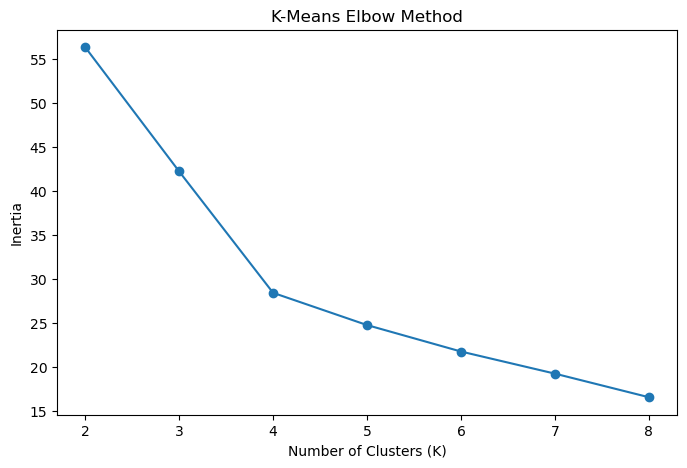

In [37]:
# Calculate K-Means inertia for different numbers of clusters
inertias = []

k_values = range(2, 9)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_crime_scaled)
    inertias.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Method")
plt.xticks(k_values)
plt.show()

c:\Users\HP\anaconda3\anaconda\envs\ml-env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HP\anaconda3\anaconda\envs\ml-env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HP\anaconda3\anaconda\envs\ml-env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HP\anaconda3\anaconda\envs\ml-env\lib\site-packages\sklearn\cluster\_kmea

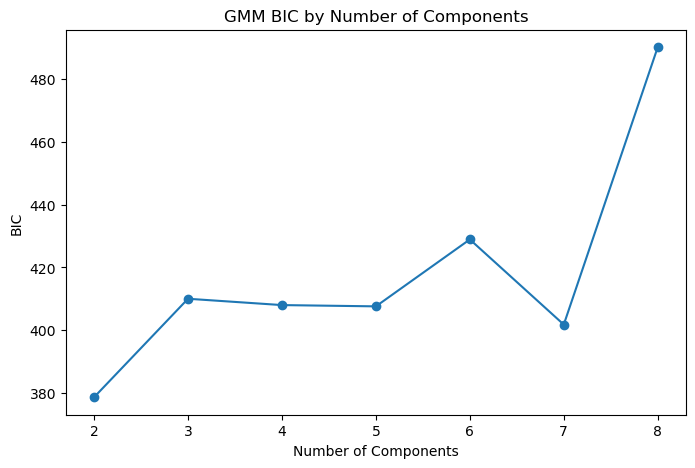

In [38]:
# Calculate GMM BIC for different numbers of components
bic_scores = []

for k in k_values:
    gmm = GaussianMixture(
        n_components=k,
        random_state=42
    )
    gmm.fit(X_crime_scaled)
    bic_scores.append(gmm.bic(X_crime_scaled))

# Plot BIC scores
plt.figure(figsize=(8, 5))
plt.plot(k_values, bic_scores, marker="o")
plt.xlabel("Number of Components")
plt.ylabel("BIC")
plt.title("GMM BIC by Number of Components")
plt.xticks(k_values)
plt.show()

## 4.5 Determining the Optimal Number of Clusters

The K-Means elbow method and GMM BIC provide different indications of the appropriate number of clusters.

For **K-Means**, the largest reduction in inertia occurs before **K = 4**, after which the improvements become smaller. The elbow is therefore identified at **K = 4**, suggesting four clusters for the K-Means model.

For the **Gaussian Mixture Model**, lower BIC values indicate a better balance between model fit and model complexity. The lowest BIC occurs at **2 components**, indicating that a two-component GMM provides the strongest fit according to this criterion.

The two methods therefore identify different cluster structures: **K-Means suggests 4 clusters, while GMM suggests 2 components**. This difference is expected because the two algorithms use different approaches to identify structure in the data.

For the remainder of the analysis, K-Means will be fitted with **K = 4**, while GMM will be fitted with **2 components**. Their resulting cluster assignments can then be compared.


In [39]:
# Fit K-Means using the K selected from the elbow method
kmeans_final = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans_final.fit_predict(X_crime_scaled)

print("K-Means cluster counts:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

K-Means cluster counts:
0     7
1    14
2    12
3    17
Name: count, dtype: int64


c:\Users\HP\anaconda3\anaconda\envs\ml-env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [40]:
# Fit GMM using the number of components selected by BIC
gmm_final = GaussianMixture(
    n_components=2,
    random_state=42
)

gmm_labels = gmm_final.fit_predict(X_crime_scaled)

print("GMM cluster counts:")
print(pd.Series(gmm_labels).value_counts().sort_index())

GMM cluster counts:
0    31
1    19
Name: count, dtype: int64


c:\Users\HP\anaconda3\anaconda\envs\ml-env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [41]:
# Create a dataframe containing the PCA coordinates and cluster assignments
cluster_results = pd.DataFrame({
    "Region": us_arrests["rownames"],
    "PC1": X_crime_pca[:, 0],
    "PC2": X_crime_pca[:, 1],
    "KMeans_Cluster": kmeans_labels,
    "GMM_Cluster": gmm_labels
})

display(cluster_results.head())

,Region,PC1,PC2,KMeans_Cluster,GMM_Cluster
0,Alabama,1.210191,-0.842277,2,1
1,Alaska,2.332187,1.539434,0,1
2,Arizona,1.518593,0.503363,0,1
3,Arkansas,0.177776,-0.328029,3,0
4,California,2.066000,1.285497,0,1


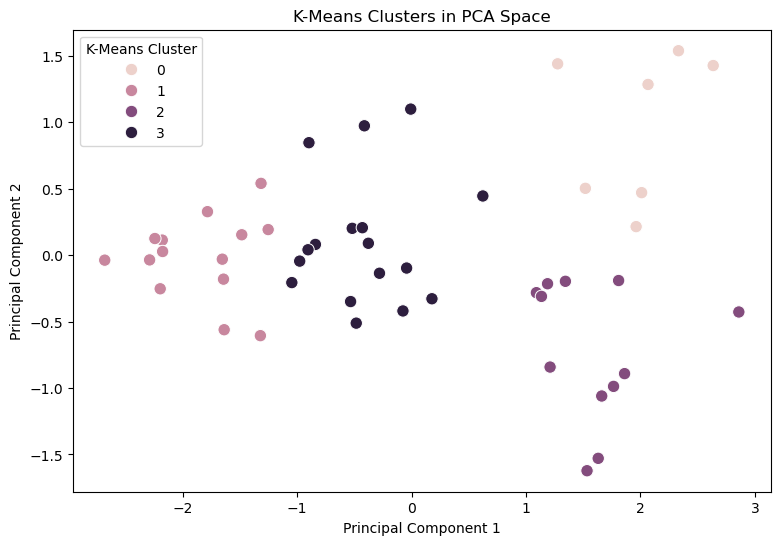

In [42]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=cluster_results,
    x="PC1",
    y="PC2",
    hue="KMeans_Cluster",
    s=80
)

plt.title("K-Means Clusters in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="K-Means Cluster")
plt.show()

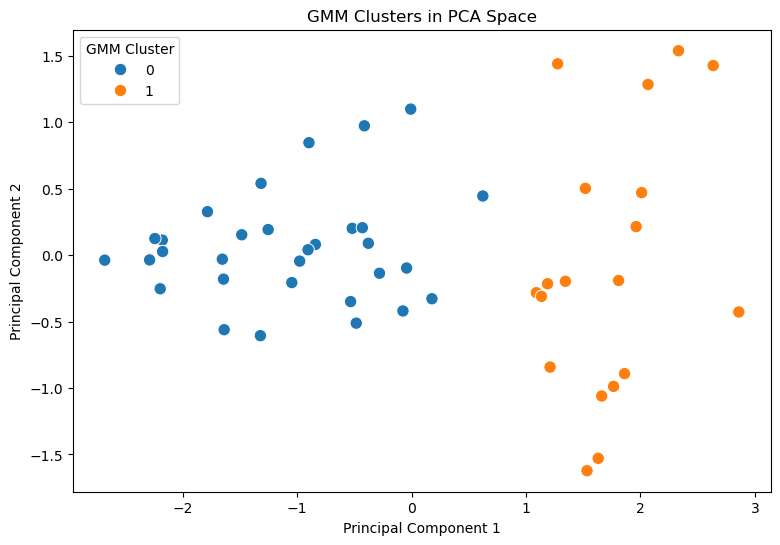

In [43]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=cluster_results,
    x="PC1",
    y="PC2",
    hue="GMM_Cluster",
    s=80
)

plt.title("GMM Clusters in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="GMM Cluster")
plt.show()

## 4.6 Visualizing Clusters in PCA Space

The clustering results were visualized by projecting the 50 regions onto the first two principal components. Since PC1 and PC2 together explain **93.89% of the total variance**, the plot provides a useful two-dimensional representation of the crime patterns.

### K-Means Clustering (K = 4)

The K-Means model divides the regions into four clusters. The clusters appear to be separated primarily along the **PC1 axis**, although PC2 also contributes to the positioning of individual observations.

Moving from lower to higher PC1 values, the regions are divided into different groups, with K-Means creating four distinct segments of the data.

This behavior is consistent with the K-Means algorithm, which assigns each observation to the nearest cluster centroid based on Euclidean distance. The resulting clusters therefore have relatively compact, distance-based boundaries.

### GMM Clustering (2 Components)

The GMM model divides the regions into two broader groups. The separation also appears to be strongly associated with **PC1**, with one group concentrated toward lower PC1 values and the other toward higher PC1 values.

This result is consistent with the BIC analysis, which identified **2 components** as the preferred number of components for the GMM.

Unlike K-Means, GMM models the data using probability distributions and estimates the probability that each observation belongs to each component. It can therefore capture cluster structures based on the distribution and variance of the observations rather than relying only on distance from a centroid.

### Comparison

The two methods produce different levels of grouping:

* **K-Means identifies 4 clusters**, providing a more detailed segmentation of the regions.
* **GMM identifies 2 broader components**, representing a simpler grouping of the same observations.
* Both methods show that **PC1 plays an important role in separating the regional crime patterns**.

The difference demonstrates that clustering results depend on the assumptions and objectives of the algorithm being used. K-Means emphasizes distance from cluster centroids, while GMM models the probability distribution of the observations.

The next step is to examine the original Murder, Assault, and Rape variables within each cluster. This will allow us to move beyond the PCA visualization and determine what the identified clusters actually represent in terms of regional crime patterns.


In [44]:
kmeans_profiles = us_arrests[crime_features].copy()

kmeans_profiles["Cluster"] = kmeans_labels

kmeans_profiles = (
    kmeans_profiles
    .groupby("Cluster")[crime_features]
    .mean()
    .round(2)
)

display(kmeans_profiles)

,Murder,Assault,Rape
Cluster,,,
0,10.10,261.29,38.29
1,3.08,80.93,11.80
2,13.63,258.17,23.92
3,6.59,145.76,20.08


In [45]:
gmm_profiles = us_arrests[crime_features].copy()

gmm_profiles["Cluster"] = gmm_labels

gmm_profiles = (
    gmm_profiles
    .groupby("Cluster")[crime_features]
    .mean()
    .round(2)
)

display(gmm_profiles)

,Murder,Assault,Rape
Cluster,,,
0,5.00,116.48,16.34
1,12.33,259.32,29.22


## 4.7 Cluster Profiles and Interpretation

The cluster profiles were examined using the original Murder, Assault, and Rape variables to understand the characteristics of each group.

### K-Means

The K-Means model identified four distinct regional profiles.

* **Cluster 1** has the lowest average values across all three crime measures, with average Murder of 3.08, Assault of 80.93, and Rape of 11.80.
* **Cluster 0** has relatively high crime levels, particularly Assault and Rape, with averages of 10.10, 261.29, and 38.29 respectively.
* **Cluster 2** has the highest average Murder rate at 13.63 and a similarly high Assault level of 258.17, while its average Rape value is 23.92.
* **Cluster 3** represents an intermediate profile, with average Murder of 6.59, Assault of 145.76, and Rape of 20.08.

This shows that K-Means provides a more detailed segmentation of the regional crime patterns. In particular, it distinguishes regions with similarly high Assault levels but different combinations of Murder and Rape.

### GMM

The GMM model identified two broader regional profiles.

**Cluster 0** has relatively lower average crime levels, with Murder of 5.00, Assault of 116.48, and Rape of 16.34.

**Cluster 1** has substantially higher average levels across all three measures, with Murder of 12.33, Assault of 259.32, and Rape of 29.22.

Therefore, the GMM solution provides a simpler separation between regions with relatively lower and higher overall crime levels.

### Comparison of K-Means and GMM

The two clustering methods reveal different levels of structure in the same dataset.

K-Means identifies **four more detailed clusters**, while GMM identifies **two broader groups**. The GMM groups can be viewed as broad crime-level profiles, while K-Means further divides these patterns according to differences in the individual crime measures.

The results demonstrate why comparing multiple clustering approaches can be useful. Different algorithms can identify different structures because they rely on different assumptions and mathematical approaches.

For this analysis, the clustering results provide a data-driven way to segment regions according to similarities in their reported crime patterns. These groups could support further investigation of regional characteristics and help analysts identify areas that warrant closer examination.


In [46]:
cluster_comparison = pd.crosstab(
    cluster_results["KMeans_Cluster"],
    cluster_results["GMM_Cluster"]
)

display(cluster_comparison)

GMM_Cluster,0,1
KMeans_Cluster,,
0,0,7
1,14,0
2,0,12
3,17,0


## 4.8 Comparing K-Means and GMM

The cross-tabulation of the two clustering solutions shows a strong structural relationship between the K-Means and GMM assignments.

The GMM model identified two broad groups:

* GMM Cluster 0 contains 31 regions.
* GMM Cluster 1 contains 19 regions.

Within these groups, K-Means provides a more detailed segmentation:

* GMM Cluster 0 corresponds to K-Means Clusters 1 and 3, containing 14 and 17 regions respectively.
* GMM Cluster 1 corresponds to K-Means Clusters 0 and 2, containing 7 and 12 regions respectively.

This indicates that the two methods identify a similar broad structure in the data, but K-Means provides a finer segmentation than GMM.

The difference is also consistent with the cluster profiles. GMM separates the regions into a relatively lower-crime group and a relatively higher-crime group, while K-Means further distinguishes regions within these broad groups based on different combinations of Murder, Assault, and Rape.

Overall, the analysis demonstrates that clustering results depend on the assumptions and level of detail provided by the chosen algorithm. Using both K-Means and GMM provides a more complete view of the regional crime patterns than relying on a single clustering method.

### Project 3 Conclusion

The Regional Crime Pattern Analysis successfully identified natural groupings among the 50 regions in the `USArrests` dataset.

After selecting Murder, Assault, and Rape and standardizing the features, PCA reduced the three variables to two components that explained **93.89% of the total variance**.

The K-Means elbow method suggested **4 clusters**, while GMM BIC identified **2 components**. The resulting clusters revealed a broad distinction between regions with relatively lower and higher crime levels, with K-Means providing additional detail within these broader groups.

These findings demonstrate how unsupervised learning can be used to segment regions according to similarities in crime patterns. Such segmentation could support further investigation of regional characteristics, resource allocation analysis, and identification of areas requiring additional study.

However, the clusters describe patterns in the available data and do not establish causal relationships between crime variables or explain why particular regions have different crime levels.


# 5. Overall Project Conclusion

This project demonstrated how different machine learning techniques can be applied to different business problems within a consulting environment.

The three projects addressed **classification, recommendation, and clustering**, requiring different analytical approaches.

### Wine Classification System

The Wine Classification project used **PCA and k-Nearest Neighbors (k-NN)** to classify wine varieties based on their chemical properties.

After standardizing the features and retaining 95% of the variance through PCA, GridSearchCV identified **18 neighbors with the Euclidean distance metric** as the best-performing combination based on cross-validation. The model achieved **97.91% mean cross-validation accuracy** and **100% accuracy on the held-out test set**.

These results indicate that the chemical measurements in the dataset contain strong information for distinguishing between the three wine classes. In a business setting, such a system could support automated classification and quality-control processes. However, performance on this dataset should not be assumed to represent performance on all future wine samples.

### Agricultural Feed Recommendation Engine

The Agricultural Feed Recommendation Engine used the `Chickwts` dataset as a proxy for feed performance.

Chicken weight was standardized and transformed using PCA, with one principal component retaining **100% of the variance** because only one numerical feature was used. Cosine similarity was then used to identify feed types with similar profiles.

The analysis identified groups of feeds with positive similarity in the one-dimensional PCA space. However, because the analysis uses only one numerical feature, cosine similarity primarily reflects whether observations lie in the same direction relative to the standardized mean. Therefore, the recommendations should be interpreted as a **prototype similarity-based recommendation system**, rather than evidence that one feed causes better growth than another.

### Regional Crime Pattern Analysis

The Regional Crime Pattern Analysis used standardized Murder, Assault, and Rape measurements to identify natural groupings among 50 regions.

PCA reduced the three crime variables to two components while retaining **93.89% of the total variance**. The K-Means elbow method suggested **4 clusters**, while GMM BIC identified **2 components**.

The GMM solution revealed two broad regional profiles with relatively lower and higher average crime levels. K-Means provided a more detailed segmentation, separating these broader patterns into four groups with different combinations of Murder, Assault, and Rape.

These clusters describe statistical patterns in the dataset and should not be interpreted as causal explanations for differences in regional crime levels.

## 5.1 Overall Business Value

Together, the three projects demonstrate how machine learning can support different types of business and organizational decisions:

| Project                | Technique                 | Business Application                              |
| ---------------------- | ------------------------- | ------------------------------------------------- |
| Wine Classification    | PCA + k-NN + GridSearchCV | Automated wine classification and quality control |
| Feed Recommendation    | PCA + Cosine Similarity   | Similarity-based feed recommendations             |
| Crime Pattern Analysis | PCA + K-Means + GMM       | Regional segmentation and pattern discovery       |

The projects also demonstrate the importance of matching the machine learning technique to the business problem. **Supervised learning** was appropriate for the Wine Classification task because a known target variable was available. **Similarity analysis** was appropriate for the Feed Recommendation task because the objective was to identify comparable observations. **Unsupervised learning** was appropriate for the Crime Pattern Analysis because there was no predefined target and the objective was to discover natural groupings.

Overall, the DataVine Analytics project demonstrates a complete machine learning workflow from **data preparation and transformation through model development, evaluation, visualization, and business interpretation**. The analysis also highlights the importance of considering model assumptions, dataset limitations, and the appropriate interpretation of machine learning results when translating analytical findings into business applications.
